In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from fastai.conv_learner import *
from fastai.dataset import *
#from Path import PATH
import gzip

In [3]:
#dataset ->lsun-bedrooms ... 4.3GB
#url = 'https://s3.amazonaws.com/fast-ai-imageclas/bedroom.tgz'

In [4]:
#PATH = Path('/home/zeus/older_pytorch_installation/nb/')

In [5]:
PATH = Path('data/lsun/')
IMG_PATH = PATH/'bedroom'
CSV_PATH = PATH/'files.csv'
TMP_PATH = PATH/'tmp'
TMP_PATH.mkdir(exist_ok=True)

In [6]:
files = PATH.glob('bedroom/**/*.jpg')

with CSV_PATH.open('w') as fo:
    for  f in files: fo.write(f'{f.relative_to(IMG_PATH)},0\n')

In [7]:
CSV_PATH = PATH/'files_sample.csv'

In [8]:
files = PATH.glob('bedroom/**/*.jpg')

with CSV_PATH.open('w') as fo:
    for f in files:
        if random.random()<0.1: fo.write(f'{f.relative_to(IMG_PATH)},0\n')

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, ni, no, ks, stride, bn=True, pad=None):
        super().__init__()
        if pad is None: pad = ks//2//stride
        self.conv = nn.Conv2d(ni, no, ks, stride, padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(ni, no, ks, stride, padding=pad, bias=False)
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x = self.relu(self.conv(x))
        return self.bn(x) if self.bn else x

In [18]:
class DCGAN_D(nn.Module):
    """ Input is an image and output a scaler number """
    def __init__(self, isize, nc, ndf, n_extra_layers=0):
        super().__init__()
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        self.initial = ConvBlock(nc, ndf, 4, 2, bn=False)
        csize,cndf = isize/2, ndf
        self.extra = nn.Sequential(*[ConvBlock(cndf, cndf, 3, 1)
                                    for t in range(n_extra_layers)])
        pyr_layers = []
        #to handle any arbirtrary size of images, and turn them to fixed size i.e. here 4x4
        #append enough stride 2 conv layers until the grid size is decreased to not bigger than 4x4
        while csize > 4: 
            pyr_layers.append(ConvBlock(cndf, cndf*2, 4, 2))
            cndf *= 2; csize /= 2
        self.pyramid = nn.Sequential(*pyr_layers)
    
        self.final = nn.Conv2d(cndf, 1, 4, padding=0, bias=False) #one channel output

    def forward(self, input):
        x = self.initial(input)
        x = self.extra(x)
        x = self.pyramid(x)
        return self.final(x).mean(0).view(1)

In [11]:
class DeconvBlock(nn.Module):
    def __init__(self, ni, no, ks, stride, pad, bn=True):
        super().__init__()
        #convTranspose is same as calculation of the gradient of conv
        self.conv = nn.ConvTranspose2d(ni, no, ks, stride, padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(no)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.conv(x))
        return self.bn(x) if self.bn else x

In [12]:
class DCGAN_G(nn.Module):
    """ Input is a vector of random number, aka from paper 'the prior' """
    def __init__(self, isize, nz, nc, ngf, n_extra_layers=0):
        super().__init__()
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        cngf, tisize = ngf//2, 4
        while tisize !=isize: cngf *=2; tisize*=2
        layers = [DeconvBlock(nz, cngf, 4, 1, 0)]

        csize,cndf = 4, cngf
        while csize < isize//2:
            layers.append(DeconvBlock(cngf, cngf//2, 4, 2, 1))
            cngf //=2; csize *= 2

        layers += [DeconvBlock(cngf, cngf, 3, 1, 1) for t in range(n_extra_layers)]
        layers.append(nn.ConvTranspose2d(cngf, nc, 4, 2, 1, bias=False))
        self.features = nn.Sequential(*layers)

    def forward(self, input): return F.tanh(self.features(input))

In [13]:
bs, sz, nz = 64, 64, 100

In [14]:
tfms = tfms_from_stats(inception_stats, sz)
md = ImageClassifierData.from_csv(PATH, 'bedroom', CSV_PATH, tfms=tfms, bs=128,
                                skip_header=False, continuous=True)

In [15]:
md = md.resize(128)

  0%|          | 0/6 [00:00<?, ?it/s]

In [16]:
x, _ = next(iter(md.val_dl))

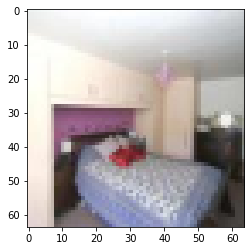

In [17]:
plt.imshow(md.trn_ds.denorm(x)[0]);